## Lecture 12 : Machine Learning using Multi-Fidelity Data

## Table of Contents
#### 1. [Setting Programming Environment](#Setting-Programming-Environment)
#### 2. [Gaussian Process Regression](#Gaussian-Process-Regression)
#### 3. [Multi-fidelity Deep Neural Network](#Multi-fidelity-Deep-Neural-Network)

## Setting Programming Environment

In [13]:
!pip install GPy

# Gaussian Process Regression

## Noiseless Data
<img src="Sample.png" width="200" height="200" alt="Alternative text" />
<img src="GP_BASIC_0.png" width="200" height="200" alt="Alternative text" />
<img src="GP_BASIC.png" alt="Alternative text" />


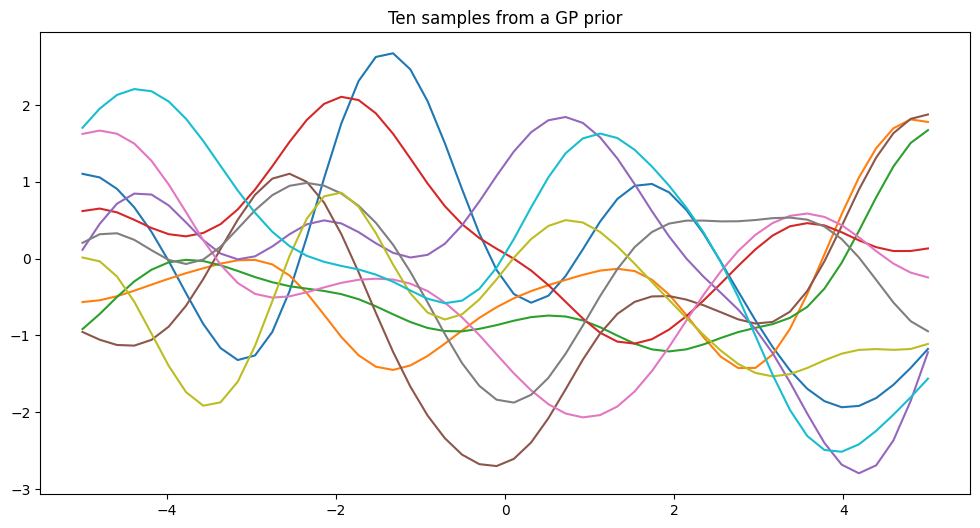

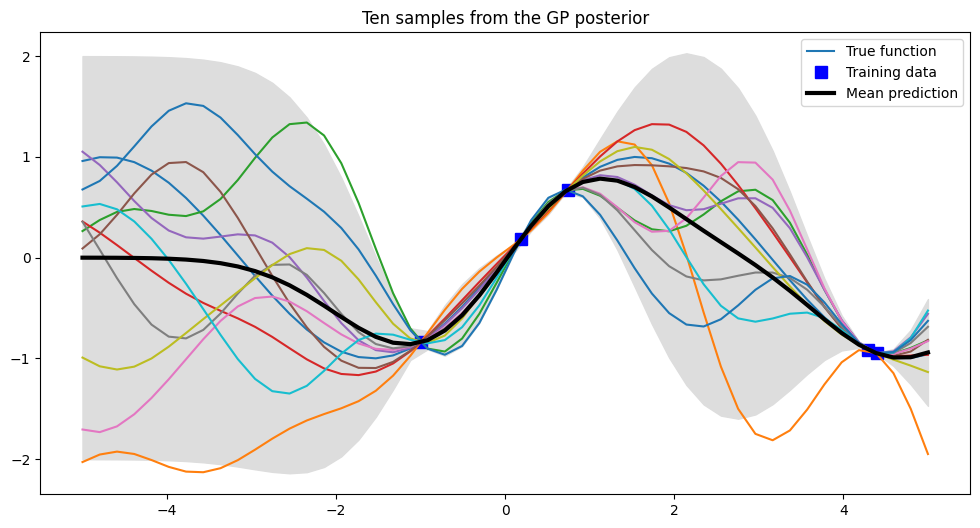

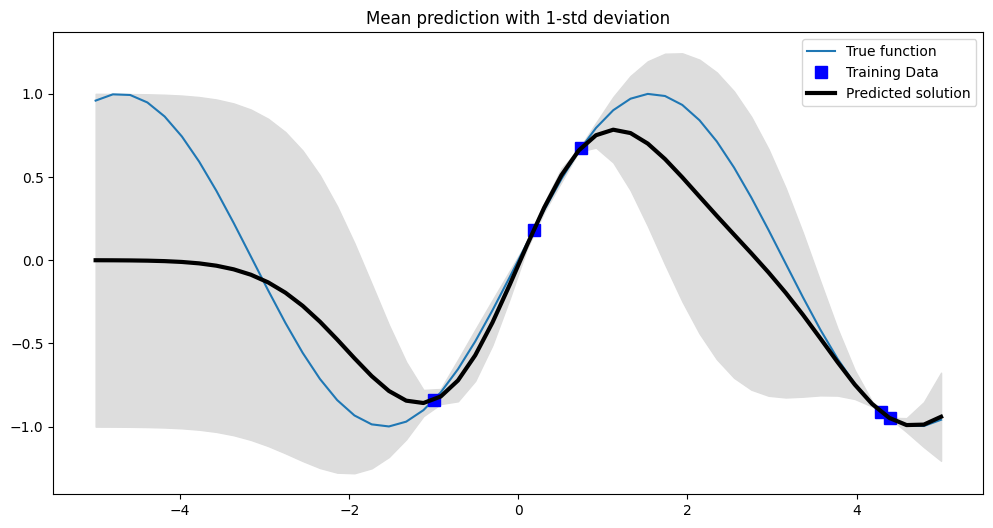

In [8]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Kernel Function
# ------------------------------------------------------------------
def kernel(a, b):
    """
    Squared Exponential (RBF) Kernel used in Gaussian Processes.

    This function computes similarity between points in 'a' and 'b'.
    The closer two points are, the higher their similarity.

    Parameters:
    a : array of shape (m, d)
    b : array of shape (n, d)

    Returns:
    Kernel matrix of shape (m, n)
    """
    kernelParameter = 1.0  # length-scale parameter (controls smoothness)

    # Compute squared Euclidean distance
    sqdist = np.sum(a**2, 1).reshape(-1, 1) + np.sum(b**2, 1) - 2 * np.dot(a, b.T)

    # Apply RBF formula
    return np.exp(-0.5 * (1 / kernelParameter) * sqdist)


# ------------------------------------------------------------------
# Data Generation
# ------------------------------------------------------------------
N = 5          # number of training points
n = 50         # number of test points
noise = 0.0    # noise variance (assumed noiseless here)

# Training data: random points between -5 and 5
Xtrain = np.random.uniform(-5, 5, size=(N, 1))
ytrain = np.sin(Xtrain)   # target function

# Test data: evenly spaced points
Xtest = np.linspace(-5, 5, n).reshape(-1, 1)


# ------------------------------------------------------------------
# Gaussian Process PRIOR
# ------------------------------------------------------------------

# Compute covariance between test points
K_ss = kernel(Xtest, Xtest)

# Add small value (jitter) for numerical stability
L = np.linalg.cholesky(K_ss + 1e-6 * np.eye(n))

# Generate samples from prior distribution
f_prior = L @ np.random.normal(size=(n, 10))

# Plot prior samples
plt.plot(Xtest, f_prior)
plt.title('Ten samples from a GP prior')
plt.show()


# ------------------------------------------------------------------
# Gaussian Process POSTERIOR
# ------------------------------------------------------------------

# Kernel between training points
K = kernel(Xtrain, Xtrain)

# Add noise to diagonal and invert
K_inv = np.linalg.inv(K + noise * np.eye(N))

# Kernel between training and test points
K_st = kernel(Xtrain, Xtest)

# Posterior mean
mu_st = K_st.T @ K_inv @ ytrain.squeeze()

# Posterior covariance
cov = K_ss - K_st.T @ K_inv @ K_st

# Standard deviation (uncertainty)
stdv = np.sqrt(np.diag(cov)).squeeze()

# Draw samples from posterior
f_post = np.random.multivariate_normal(
    mean=mu_st.squeeze(),
    cov=cov,
    size=10
).T


# ------------------------------------------------------------------
# Plot Posterior Samples
# ------------------------------------------------------------------
plt.plot(Xtest, np.sin(Xtest), label="True function")
plt.plot(Xtrain, ytrain, 'bs', ms=8, label="Training data")
plt.plot(Xtest, f_post)
plt.gca().fill_between(
    Xtest.flat,
    mu_st - 2 * stdv,
    mu_st + 2 * stdv,
    color="#dddddd"
)
plt.plot(Xtest, mu_st, 'k-', lw=3, label="Mean prediction")
plt.title('Ten samples from the GP posterior')
plt.legend()
plt.show()


# ------------------------------------------------------------------
# Plot Mean Prediction with Uncertainty
# ------------------------------------------------------------------
plt.plot(Xtest, np.sin(Xtest), label="True function")
plt.plot(Xtrain, ytrain, 'bs', ms=8, label="Training Data")
plt.plot(Xtest, mu_st, 'k-', lw=3, label="Predicted solution")

# 1 standard deviation confidence interval
plt.gca().fill_between(
    Xtest.flat,
    mu_st - 1.0 * stdv,
    mu_st + 1.0 * stdv,
    color="#dddddd"
)

plt.title('Mean prediction with 1-std deviation')
plt.legend()
plt.show()

## GPR With Noisy Data 

<font size = "5">$y = f(x) + \epsilon,~~\epsilon \sim \mathcal{N}(0, \sigma_y^2)\\$
$\mathbf{K}_y = \mathbf{K} + \sigma_y^2 \mathbf{I}$
<img src="GP_NP.png" alt="Alternative text" />


<img src="GP_BASIC_NL.png" alt="Alternative text" />

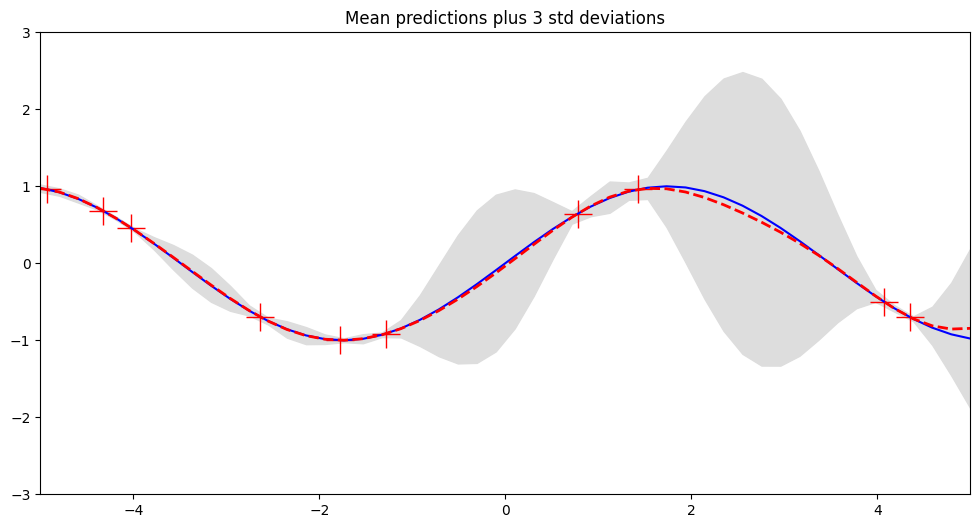

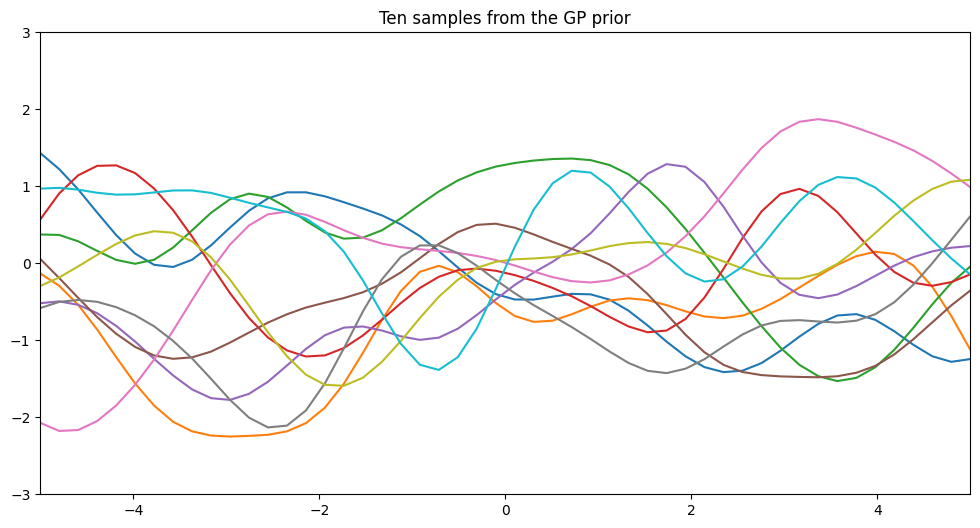

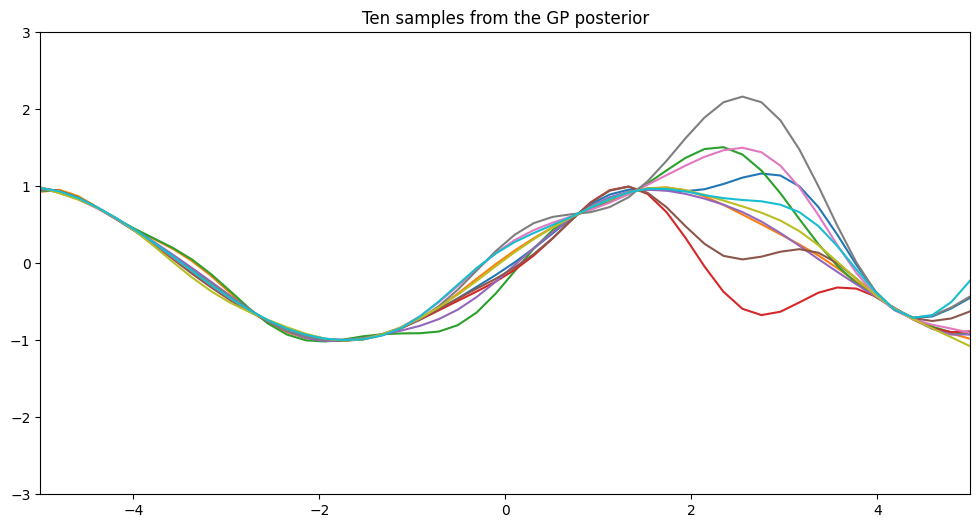

In [9]:
from __future__ import division  # ensures proper division (useful for Python 2 compatibility)

import numpy as np
import matplotlib.pyplot as pl


# ------------------------------------------------------------------
# True function (unknown in real problems)
# ------------------------------------------------------------------
# This is the function we want to approximate using GP
f = lambda x: np.sin(0.9 * x).flatten()


# ------------------------------------------------------------------
# Kernel Function (Squared Exponential / RBF)
# ------------------------------------------------------------------
def kernel(a, b):
    """
    Computes similarity between points using RBF kernel.
    
    Closer points → higher similarity
    Distant points → lower similarity
    """
    kernelParameter = 1  # controls smoothness

    # Compute squared Euclidean distance
    sqdist = np.sum(a**2, 1).reshape(-1, 1) + np.sum(b**2, 1) - 2 * np.dot(a, b.T)

    # Apply kernel formula
    return np.exp(-0.5 * (1 / kernelParameter) * sqdist)


# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
N = 10        # number of training points
n = 50        # number of test points
s = 0.00005   # noise variance


# ------------------------------------------------------------------
# Generate Training Data
# ------------------------------------------------------------------
# Random input samples
X = np.random.uniform(-5, 5, size=(N, 1))

# Observations with noise added
y = f(X) + s * np.random.randn(N)


# ------------------------------------------------------------------
# Compute Kernel Matrix for Training Data
# ------------------------------------------------------------------
K = kernel(X, X)

# Cholesky decomposition for numerical stability
L = np.linalg.cholesky(K + s * np.eye(N))


# ------------------------------------------------------------------
# Test Points (where predictions are made)
# ------------------------------------------------------------------
Xtest = np.linspace(-5, 5, n).reshape(-1, 1)


# ------------------------------------------------------------------
# Compute Posterior Mean
# ------------------------------------------------------------------
# Solve linear system instead of direct inversion (more stable)
Lk = np.linalg.solve(L, kernel(X, Xtest))

# Mean prediction
mu = np.dot(Lk.T, np.linalg.solve(L, y))


# ------------------------------------------------------------------
# Compute Posterior Variance (Uncertainty)
# ------------------------------------------------------------------
K_ = kernel(Xtest, Xtest)

# Variance formula
s2 = np.diag(K_) - np.sum(Lk**2, axis=0)

# Standard deviation
s = np.sqrt(s2)


# ------------------------------------------------------------------
# Plot: Predictions + Uncertainty
# ------------------------------------------------------------------
pl.figure(1)
pl.clf()

# Training data (red +)
pl.plot(X, y, 'r+', ms=20)

# True function (blue line)
pl.plot(Xtest, f(Xtest), 'b-')

# Uncertainty region (±3 standard deviations)
pl.gca().fill_between(Xtest.flat, mu - 3 * s, mu + 3 * s, color="#dddddd")

# Predicted mean (red dashed line)
pl.plot(Xtest, mu, 'r--', lw=2)

pl.title('Mean predictions plus 3 std deviations')
pl.axis([-5, 5, -3, 3])
pl.savefig('predictive.png', bbox_inches='tight')


# ------------------------------------------------------------------
# Draw Samples from PRIOR
# ------------------------------------------------------------------
# Prior = before seeing training data
L = np.linalg.cholesky(K_ + 1e-6 * np.eye(n))

# Generate 10 random functions
f_prior = np.dot(L, np.random.normal(size=(n, 10)))

pl.figure(2)
pl.clf()
pl.plot(Xtest, f_prior)
pl.title('Ten samples from the GP prior')
pl.axis([-5, 5, -3, 3])
pl.savefig('prior.png', bbox_inches='tight')


# ------------------------------------------------------------------
# Draw Samples from POSTERIOR
# ------------------------------------------------------------------
# Posterior = after seeing training data
L = np.linalg.cholesky(K_ + 1e-6 * np.eye(n) - np.dot(Lk.T, Lk))

# Add mean + random variation
f_post = mu.reshape(-1, 1) + np.dot(L, np.random.normal(size=(n, 10)))

pl.figure(3)
pl.clf()
pl.plot(Xtest, f_post)
pl.title('Ten samples from the GP posterior')
pl.axis([-5, 5, -3, 3])
pl.savefig('post.png', bbox_inches='tight')


# ------------------------------------------------------------------
# Show all plots
# ------------------------------------------------------------------
pl.show()

## Using GPy

  std_periodic.  |  value  |  constraints  |  priors
  variance       |    1.0  |      +ve      |        
  period         |    1.0  |      +ve      |        
  lengthscale    |    1.0  |      +ve      |        


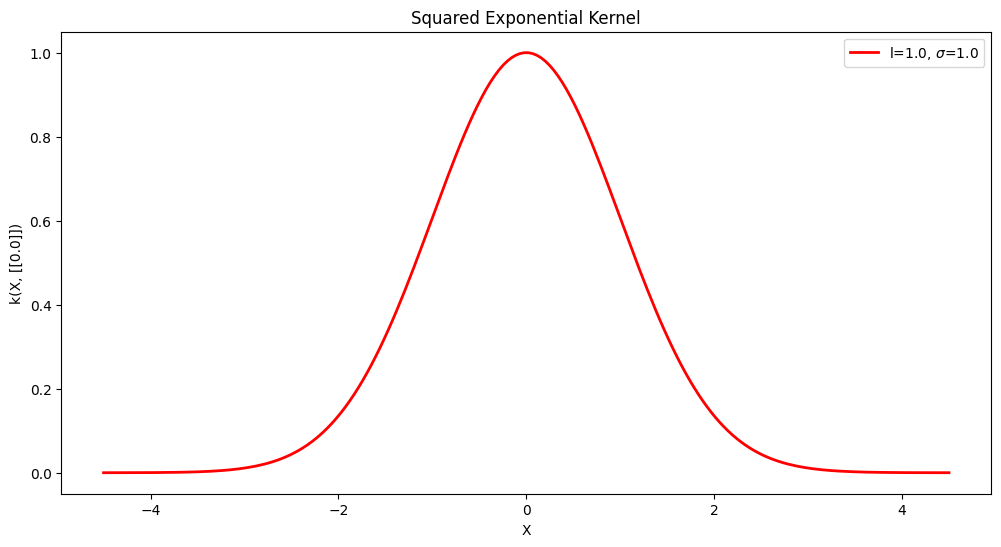

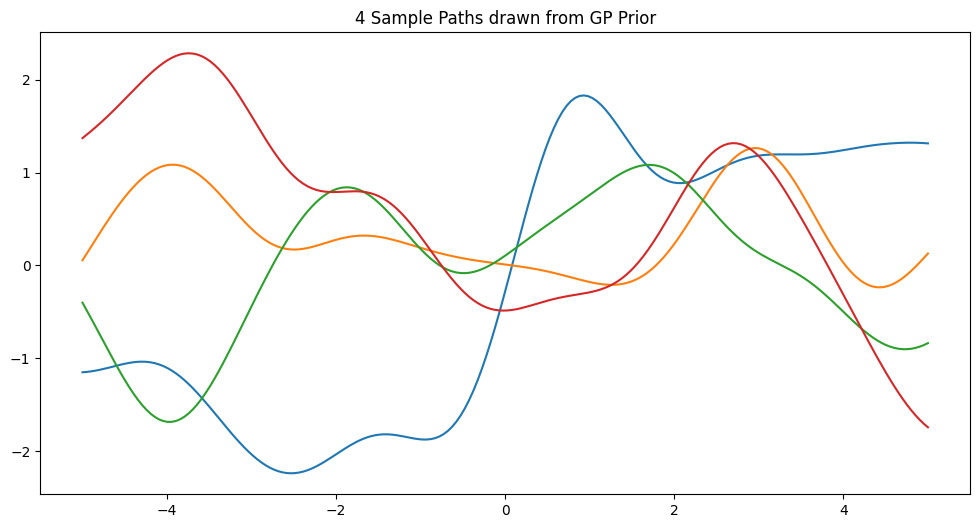

Text(0.5, 1.0, '4 Sample Paths drawn from GP Prior')

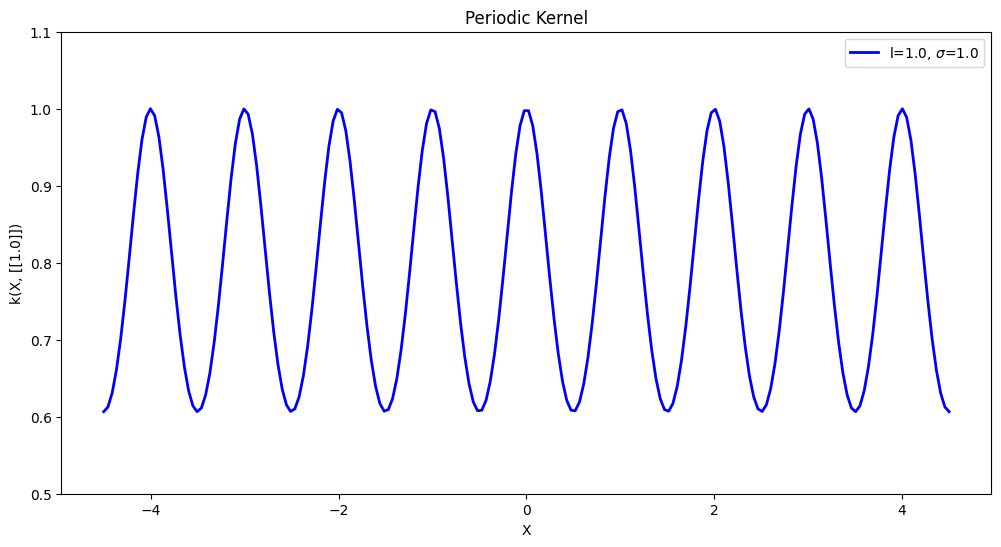

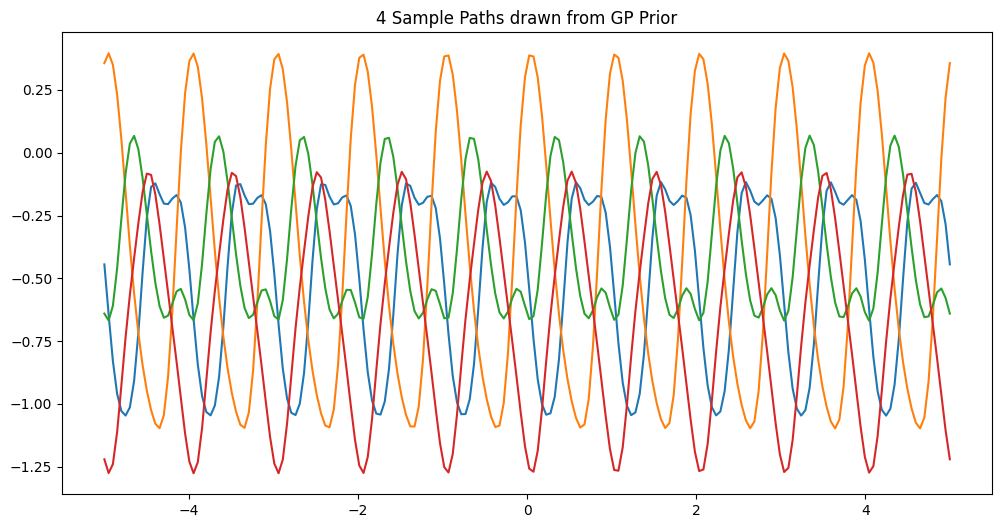

In [10]:
import GPy
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside notebook
%matplotlib inline

# Set default figure size for all plots
plt.rcParams["figure.figsize"] = (12, 6)


# ------------------------------------------------------------------
# Define Kernels
# ------------------------------------------------------------------
# RBF (Squared Exponential) kernel:
# Produces very smooth functions
ker1 = GPy.kern.RBF(input_dim=1, variance=1.0, lengthscale=1.0)

# Standard Periodic kernel:
# Produces repeating / oscillating functions
ker2 = GPy.kern.StdPeriodic(input_dim=1, variance=1.0, lengthscale=1.0)

# Print details of the periodic kernel
print(ker2)


# ------------------------------------------------------------------
# Create 1D Input Points
# ------------------------------------------------------------------
xmin = -5
xmax = 5
N = 200

# Generate 200 evenly spaced 1D points between -5 and 5
# Shape becomes (200,1), which means 200 points in 1D
X = np.linspace(xmin, xmax, N)[:, None]

# Mean vector for GP prior
# We assume zero mean at all input points
mu = np.zeros((N))


# ------------------------------------------------------------------
# GP Prior using RBF Kernel
# ------------------------------------------------------------------
# Compute covariance matrix between all pairs of input points
# This tells us how strongly each x-value is related to every other x-value
C = ker1.K(X, X)

# Plot the kernel itself
fig, ax = plt.subplots()
ker1.plot(ax=ax, linewidth=2, color="r", label="l=1.0, $\sigma$=1.0")
ax.legend()
ax.set_title("Squared Exponential Kernel")

# Draw 4 random sample functions from the GP prior
# Each sampled curve follows the smoothness pattern imposed by the RBF kernel
Z1 = np.random.multivariate_normal(mu, C, 4)

# Plot the 4 sampled functions
fig1, ax1 = plt.subplots()
for i in range(4):
    plt.plot(X[:], Z1[i, :])

ax1.set_title("4 Sample Paths drawn from GP Prior")
plt.show()


# ------------------------------------------------------------------
# GP Prior using Periodic Kernel
# ------------------------------------------------------------------
# Plot the periodic kernel
fig2, ax2 = plt.subplots()
ker2.plot(ax=ax2, linewidth=2, color="b", label="l=1.0, $\sigma$=1.0")
ax2.legend(loc="upper right")
ax2.set_title("Periodic Kernel")
ax2.set_ylim([0.5, 1.1])

# Compute covariance matrix using periodic kernel
C2 = ker2.K(X, X)

# Draw 4 random sample functions from the GP prior
# These samples will show repeating periodic behavior
Z2 = np.random.multivariate_normal(mu, C2, 4)

# Plot the 4 sampled periodic functions
fig3, ax3 = plt.subplots()
for i in range(4):
    plt.plot(X[:], Z2[i, :])

ax3.set_title("4 Sample Paths drawn from GP Prior")

## Using Gaussian Process regression

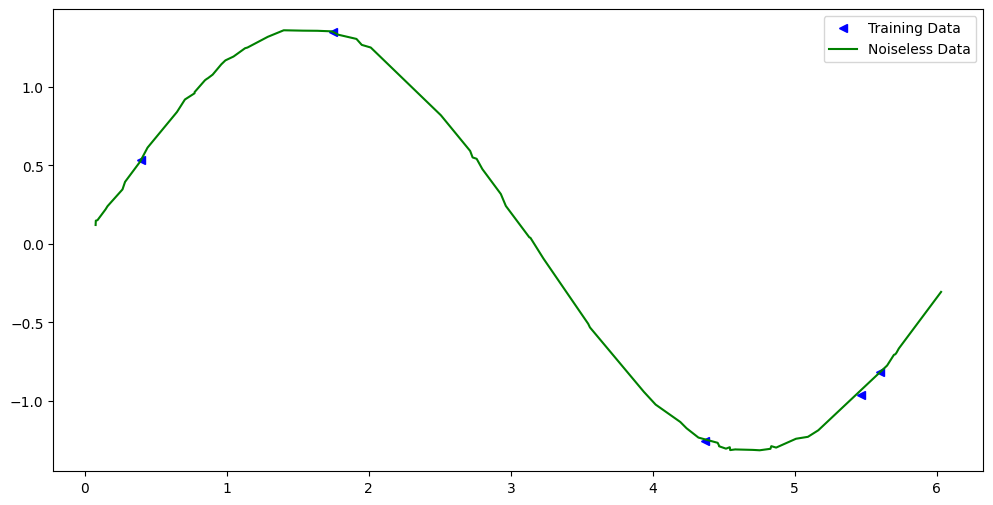


Name : GP regression
Objective : 7.121741071582965
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |  value  |  constraints  |  priors
  rbf.variance             |    1.0  |      +ve      |        
  rbf.lengthscale          |    1.0  |      +ve      |        
  Gaussian_noise.variance  |    1.0  |      +ve      |        



Name : GP regression
Objective : 3.8032903946709826
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                  value  |  constraints  |  priors
  rbf.variance             |     0.9456872330809858  |      +ve      |        
  rbf.lengthscale          |     1.2206524139574255  |      +ve      |        
  Gaussian_noise.variance  |  2.110356827832617e-08  |      +ve      |        


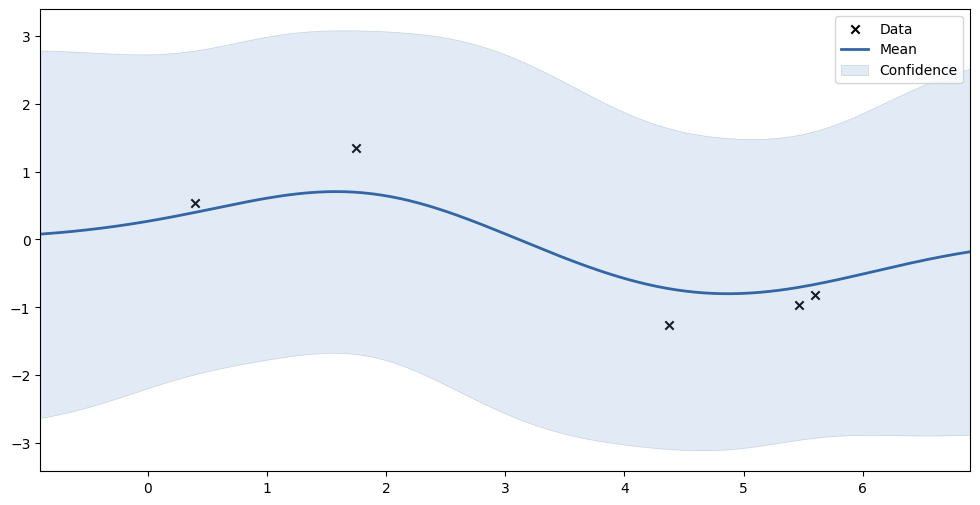

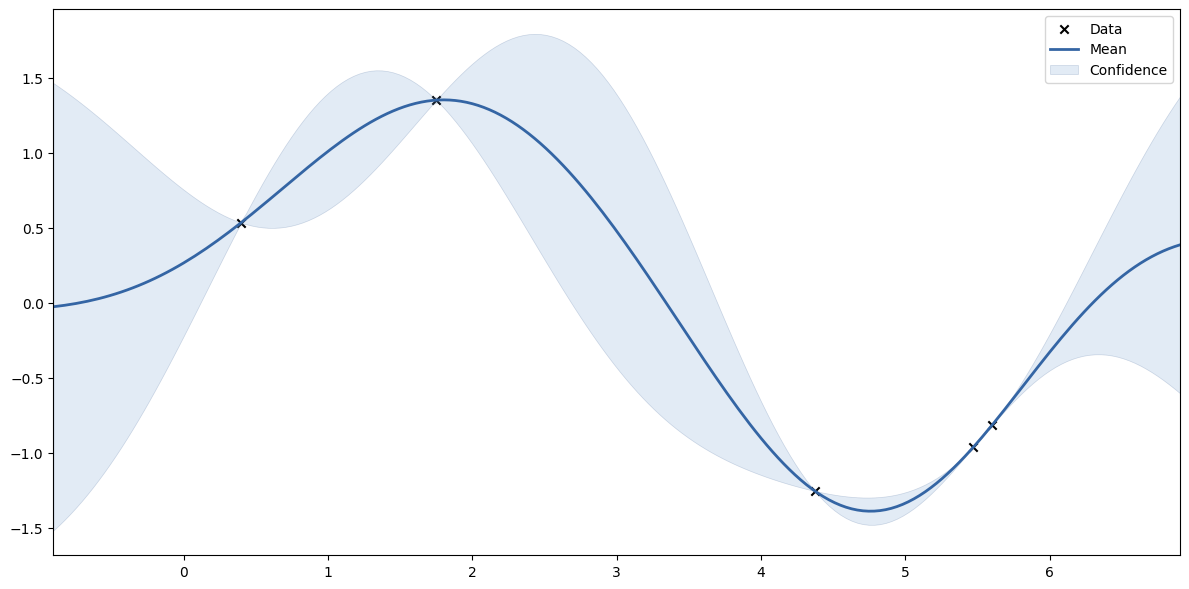

In [12]:
import GPy
import numpy as np
import matplotlib.pyplot as plt

np.int = int


# ------------------------------------------------------------------
# Define number of points
# ------------------------------------------------------------------
N = 5       # number of training points
Nstar = 70  # number of test points


# ------------------------------------------------------------------
# Generate 1D input data
# ------------------------------------------------------------------
# Create total (N + Nstar) random points between 0 and 6.14
# Sort them so they appear in increasing order
X = np.sort(np.random.rand(N + Nstar, 1) * 6.14, axis=0)

# Generate output values using sin(x) and add small Gaussian noise
Y = np.sin(X) + np.random.randn(*X.shape) * 0.008


# ------------------------------------------------------------------
# Randomly split data into training and test sets
# ------------------------------------------------------------------
# Create a random permutation of all indices
perm = np.random.permutation(X.shape[0])

# Select N points for training
x_tr = X[np.sort(perm[0:N], axis=0), :]
Y_tr = Y[np.sort(perm[0:N], axis=0), :]

# Select the remaining Nstar points for testing
x_star = X[np.sort(perm[N:N + Nstar], axis=0), :]
Y_star = Y[np.sort(perm[N:N + Nstar], axis=0), :]


# ------------------------------------------------------------------
# Normalize output data
# ------------------------------------------------------------------
# Compute mean and standard deviation using all Y values
Ymean = Y.mean()
Ystd = Y.std()

# Normalize training outputs
Y_tr -= Ymean
Y_tr /= Ystd

# Normalize test outputs
Y_star -= Ymean
Y_star /= Ystd


# ------------------------------------------------------------------
# Plot training and test data
# ------------------------------------------------------------------
plt.plot(x_tr, Y_tr, 'b<', label='Training Data')   # blue markers
plt.plot(x_star, Y_star, '-g', label='Noiseless Data')  # green curve/points
plt.legend()
plt.show()


# ------------------------------------------------------------------
# Define kernel
# ------------------------------------------------------------------
# Number of input dimensions
# Since data is 1D, dim_1 = 1
dim_1 = x_tr.shape[1]

# Define RBF kernel (also called Squared Exponential kernel)
# This kernel assumes the function is smooth
k = GPy.kern.RBF(dim_1)


# ------------------------------------------------------------------
# Create Gaussian Process Regression model
# ------------------------------------------------------------------
m = GPy.models.GPRegression(X=x_tr, Y=Y_tr, kernel=k)

# Print model details before optimization
print(m)


# ------------------------------------------------------------------
# Plot initial GP model
# ------------------------------------------------------------------
fig, ax = plt.subplots()
m.plot(ax=ax)


# ------------------------------------------------------------------
# Optimize model parameters
# ------------------------------------------------------------------
# This step adjusts kernel parameters automatically
# to better fit the training data
m.optimize(messages=1)


# ------------------------------------------------------------------
# Plot optimized model
# ------------------------------------------------------------------
m.plot()

# Print updated model details after optimization
print(m)

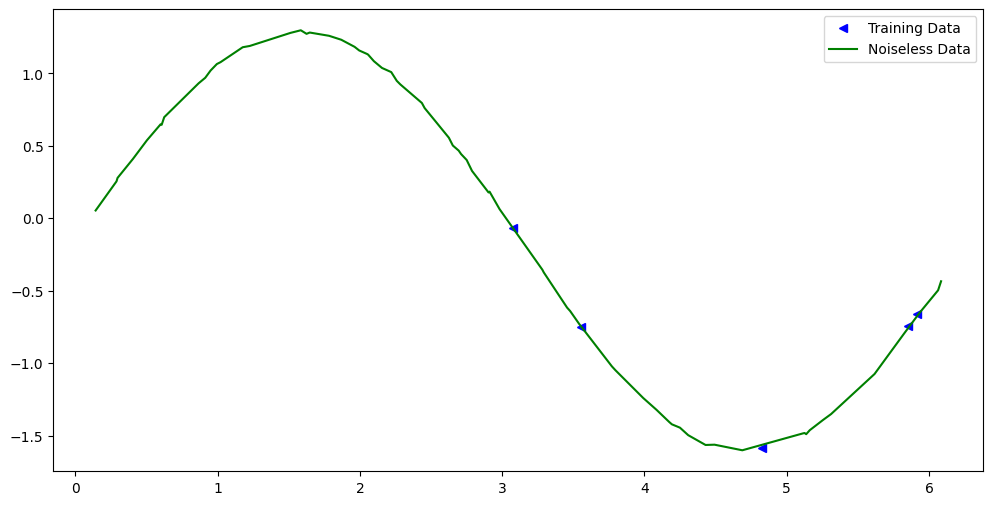


Name : GP regression
Objective : 6.710212036419886
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |  value  |  constraints  |  priors
  rbf.variance             |    1.0  |      +ve      |        
  rbf.lengthscale          |    1.0  |      +ve      |        
  Gaussian_noise.variance  |    1.0  |      +ve      |        


AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

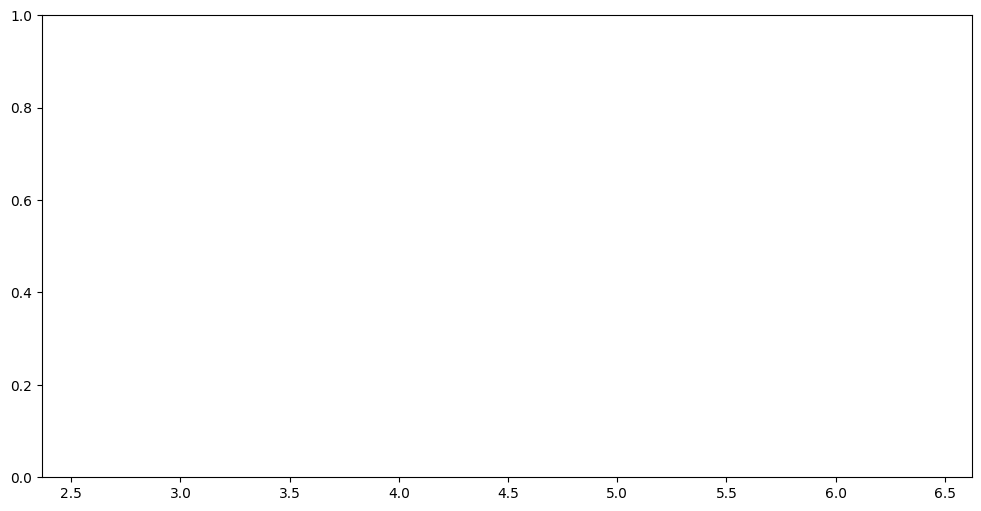

In [4]:
import GPy
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Define number of points
# ------------------------------------------------------------------
N = 5       # number of training points
Nstar = 70  # number of test points


# ------------------------------------------------------------------
# Generate 1D input data
# ------------------------------------------------------------------
# Create total (N + Nstar) random points between 0 and 6.14
# Sort them so they appear in increasing order
X = np.sort(np.random.rand(N + Nstar, 1) * 6.14, axis=0)

# Generate output values using sin(x) and add small Gaussian noise
Y = np.sin(X) + np.random.randn(*X.shape) * 0.008


# ------------------------------------------------------------------
# Randomly split data into training and test sets
# ------------------------------------------------------------------
# Create a random permutation of all indices
perm = np.random.permutation(X.shape[0])

# Select N points for training
x_tr = X[np.sort(perm[0:N], axis=0), :]
Y_tr = Y[np.sort(perm[0:N], axis=0), :]

# Select the remaining Nstar points for testing
x_star = X[np.sort(perm[N:N + Nstar], axis=0), :]
Y_star = Y[np.sort(perm[N:N + Nstar], axis=0), :]


# ------------------------------------------------------------------
# Normalize output data
# ------------------------------------------------------------------
# Compute mean and standard deviation using all Y values
Ymean = Y.mean()
Ystd = Y.std()

# Normalize training outputs
Y_tr -= Ymean
Y_tr /= Ystd

# Normalize test outputs
Y_star -= Ymean
Y_star /= Ystd


# ------------------------------------------------------------------
# Plot training and test data
# ------------------------------------------------------------------
plt.plot(x_tr, Y_tr, 'b<', label='Training Data')   # blue markers
plt.plot(x_star, Y_star, '-g', label='Noiseless Data')  # green curve/points
plt.legend()
plt.show()


# ------------------------------------------------------------------
# Define kernel
# ------------------------------------------------------------------
# Number of input dimensions
# Since data is 1D, dim_1 = 1
dim_1 = x_tr.shape[1]

# Define RBF kernel (also called Squared Exponential kernel)
# This kernel assumes the function is smooth
k = GPy.kern.RBF(dim_1)


# ------------------------------------------------------------------
# Create Gaussian Process Regression model
# ------------------------------------------------------------------
m = GPy.models.GPRegression(X=x_tr, Y=Y_tr, kernel=k)

# Print model details before optimization
print(m)


# ------------------------------------------------------------------
# Plot initial GP model
# ------------------------------------------------------------------
fig, ax = plt.subplots()
m.plot(ax=ax)


# ------------------------------------------------------------------
# Optimize model parameters
# ------------------------------------------------------------------
# This step adjusts kernel parameters automatically
# to better fit the training data
m.optimize(messages=1)


# ------------------------------------------------------------------
# Plot optimized model
# ------------------------------------------------------------------
m.plot()

# Print updated model details after optimization
print(m)

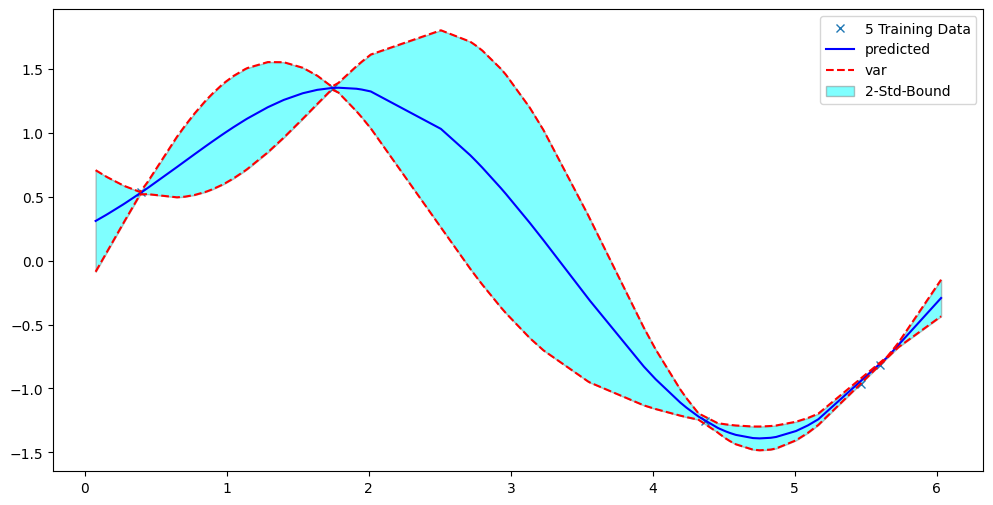

In [13]:
mu,var = m.predict(x_star)
plt.plot(x_tr, Y_tr, "x", label="5 Training Data")
plt.plot(x_star, mu, '-b',label='predicted')
plt.plot(x_star, mu+2*np.sqrt(var), 'r--',label='var')
plt.plot(x_star, mu-2*np.sqrt(var), 'r--')
plt.legend()
vv = 2*np.sqrt(var)
plt.fill_between(x_star[:,0], (mu-vv)[:,0], (mu+vv)[:,0], alpha=0.5, edgecolor='gray', facecolor='cyan',\
                 label="2-Std-Bound")
plt.legend()
#plt.ylim((-2.5, 2.5))
plt.show()
#Y_sim = m.posterior_samples(x_star)
#plt.plot(x_star, Y_sim[:,0,:])



## Different Kernels

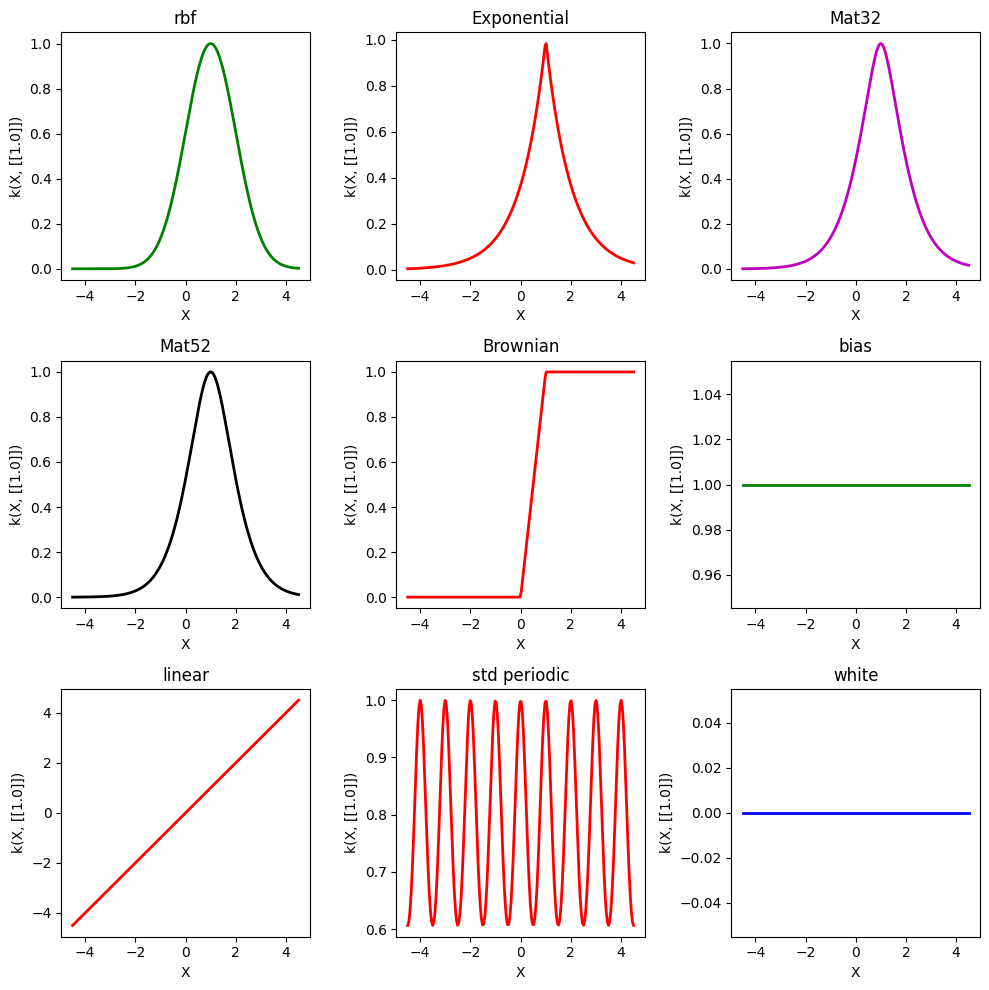

In [15]:
from random import randrange
import GPy
import matplotlib.pyplot as plt
import numpy as np

figure, axes = plt.subplots(3,3, figsize=(10,10), tight_layout=True)
kerns = [GPy.kern.RBF(1), GPy.kern.Exponential(1), GPy.kern.Matern32(1), \
         GPy.kern.Matern52(1), GPy.kern.Brownian(1), GPy.kern.Bias(1), \
         GPy.kern.Linear(1), GPy.kern.StdPeriodic(1), GPy.kern.White(1)]

col = ['r', 'b', 'g', 'b', 'm', 'k']

for k,a in zip(kerns, axes.flatten()):
    j = np.random.randint(0, high=6, size=1, dtype=int)
    k.plot(ax=a, x=1, color=col[j[0]])
    a.set_title(k.name.replace('_', ' '))

# Matern Kernels with Different Length Scale

  Mat52.       |  value  |  constraints  |  priors
  variance     |    1.0  |      +ve      |        
  lengthscale  |    1.0  |      +ve      |        


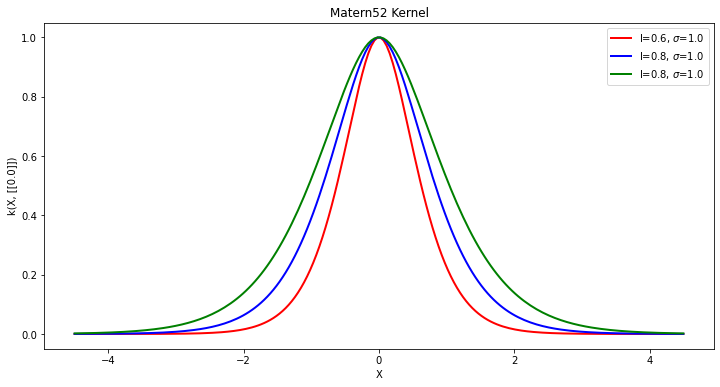

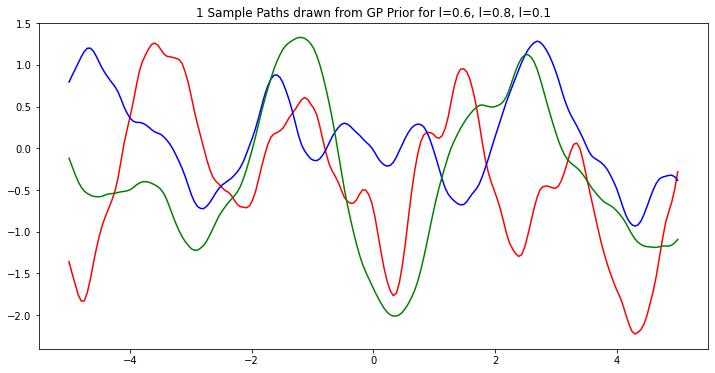

In [10]:
import GPy
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12, 6)

# Define Kernel Using GPy
ker1 = GPy.kern.Matern52(input_dim=1, variance = 1.0, lengthscale=0.6)
ker2 = GPy.kern.Matern52(input_dim=1, variance = 1.0, lengthscale=0.8)
ker3 = GPy.kern.Matern52(input_dim=1, variance = 1.0, lengthscale=1.0)

xmin=-5
xmax=5
N=200
X = np.linspace(xmin, xmax, N)[:, None]
mu = np.zeros((N)) 
C1 = ker1.K(X,X)
C2 = ker2.K(X,X)
C3 = ker3.K(X,X)
fig, ax = plt.subplots()
ker1.plot(ax=ax, linewidth=2, color="r", label="l=0.6, $\sigma$=1.0")
ker2.plot(ax=ax, linewidth=2, color="b", label="l=0.8, $\sigma$=1.0")
ker3.plot(ax=ax, linewidth=2, color="g", label="l=0.8, $\sigma$=1.0")
ax.legend()
ax.set_title("Matern52 Kernel")

Z1 = np.random.multivariate_normal(mu,C1,1)
Z2 = np.random.multivariate_normal(mu,C2,1)
Z3 = np.random.multivariate_normal(mu,C3,1)
fig, ax = plt.subplots() 
plt.plot(X[:],Z1[0,:], "-r")
plt.plot(X[:],Z2[0,:], "-b")
plt.plot(X[:],Z3[0,:], "-g")

ax.set_title("1 Sample Paths drawn from GP Prior for l=0.6, l=0.8, l=0.1")
plt.show()


In [2]:
%pip install notutils
%pip install mlai
%pip install gpy
%pip install pyDOE
%pip install emukit
%pip install --upgrade numpy

  Using cached notutils-0.0.1-py3-none-any.whl (4.5 kB)
Note: you may need to restart the kernel to use updated packages.
  Using cached mlai-0.1.2-py2.py3-none-any.whl (42 kB)
  Using cached pods-0.1.13-py2.py3-none-any.whl (56 kB)
Note: you may need to restart the kernel to use updated packages.
     |████████████████████████████████| 1.5 MB 5.0 MB/s eta 0:00:01
  Using cached paramz-0.9.5.tar.gz (71 kB)
  Created wheel for paramz: filename=paramz-0.9.5-py3-none-any.whl size=102565 sha256=71f2d580a655a868c59140a7e2d9a454d263637e9cfdc594e09cb820b9e7b990
  Stored in directory: /Users/raj/Library/Caches/pip/wheels/c8/95/f5/ce28482da28162e6028c4b3a32c41d147395825b3cd62bc810
Successfully built paramz
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached emukit-0.4.9-py3-none-any.whl (241 kB)
  Using cached emcee-3.1.1-py2.py3-none-any.whl (45 kB)
     |████████████████████████████████| 26.5 MB 5.3

  Using cached tenacity-8.0.1-py3-none-any.whl (24 kB)
Note: you may need to restart the kernel to use updated packages.
     |████████████████████████████████| 16.9 MB 4.7 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.20.3
    Uninstalling numpy-1.20.3:
      Successfully uninstalled numpy-1.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.4.0 requires daal==2021.3.0, which is not installed.
numba 0.54.1 requires numpy<1.21,>=1.17, but you have numpy 1.21.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


## Multifidelity GPR

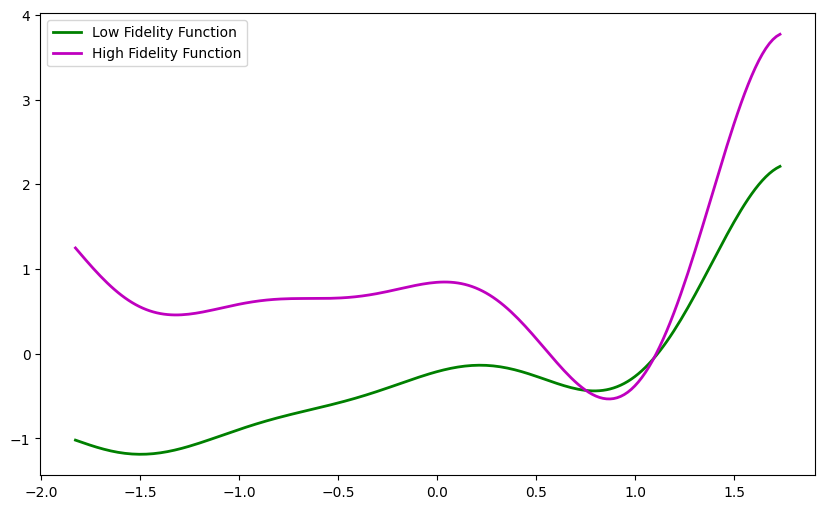

Optimization restart 1/25, f = -6.342520898336709
Optimization restart 2/25, f = -6.342521014824495
Optimization restart 3/25, f = -6.342521132068411
Optimization restart 4/25, f = -6.3425210852291025
Optimization restart 5/25, f = -6.342307263888105
Optimization restart 6/25, f = -6.3425212102761614
Optimization restart 7/25, f = -6.342521257886532
Optimization restart 8/25, f = -6.3425212541579965
Optimization restart 9/25, f = -6.342520949801971
Optimization restart 10/25, f = -6.3425211801279735
Optimization restart 11/25, f = -6.342521013238191
Optimization restart 12/25, f = -6.342521070229777
Optimization restart 13/25, f = -6.342521143361872
Optimization restart 14/25, f = -6.34252111595267
Optimization restart 15/25, f = -6.342520519198143
Optimization restart 16/25, f = -6.342521127047302
Optimization restart 17/25, f = -6.3425208974810925
Optimization restart 18/25, f = -5.6564357271433945
Optimization restart 19/25, f = -6.342520970250252
Optimization restart 20/25, f = -6.

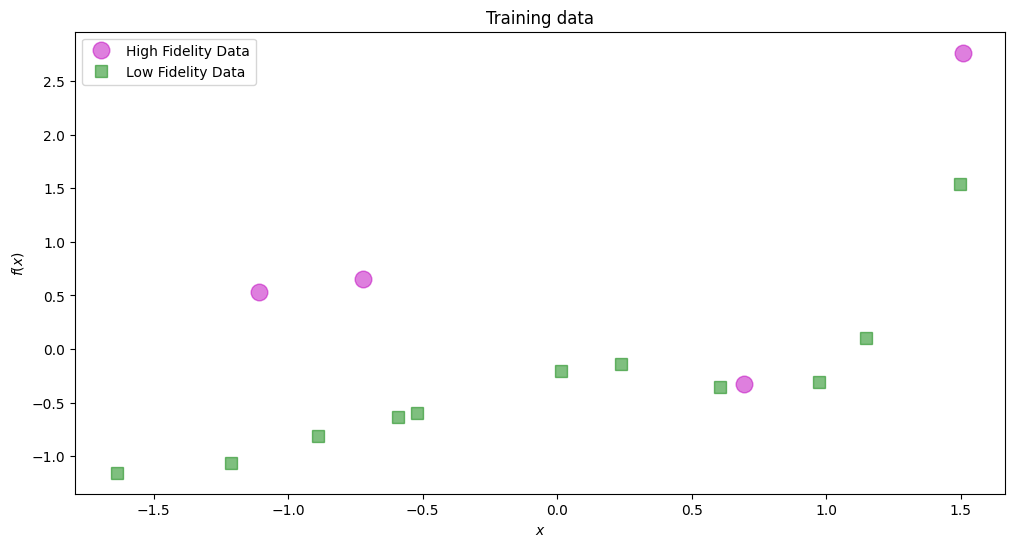

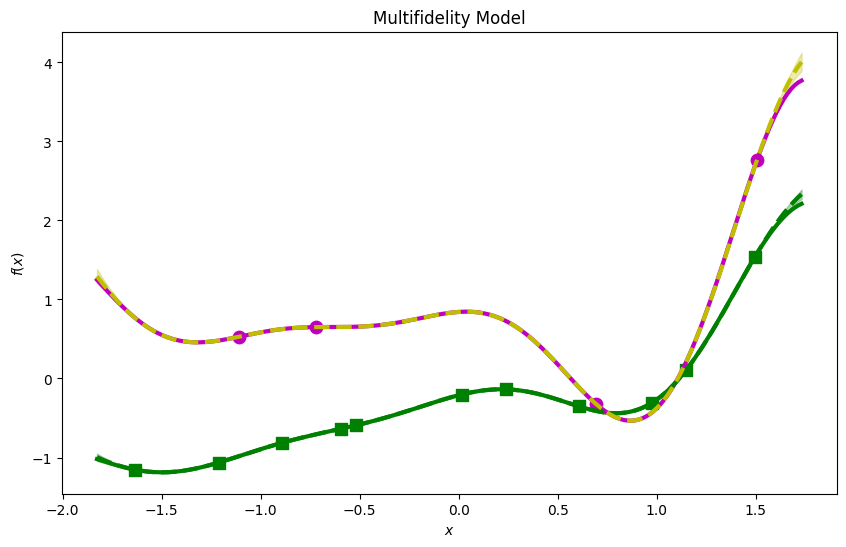

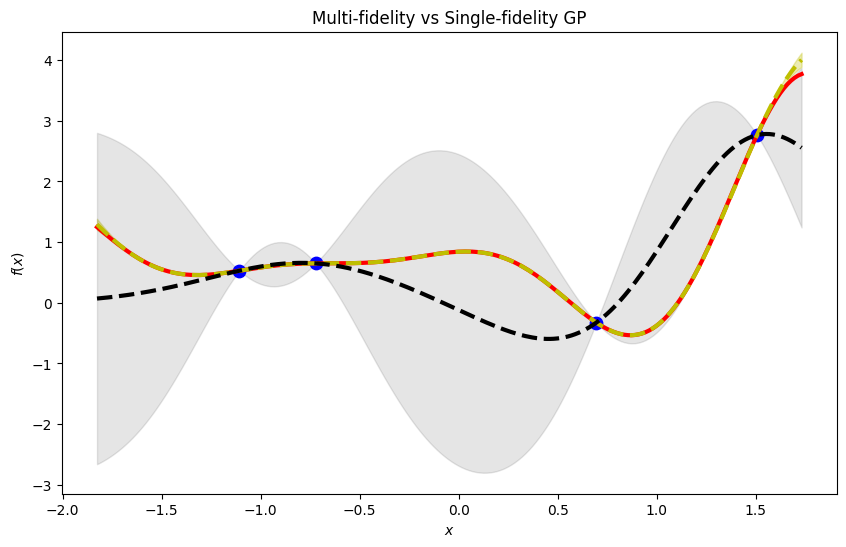

In [19]:
import numpy as np
np.random.seed(20)   # Fix random seed for reproducibility

import GPy
import mlai.plot as plot
import mlai
import emukit.multi_fidelity
import emukit.test_functions

np.float = float
np.bool = bool

# Wrappers for multi-fidelity GP models
from emukit.model_wrappers.gpy_model_wrappers import GPyMultiOutputWrapper
from emukit.multi_fidelity.models import GPyLinearMultiFidelityModel

# Utility functions to format data for multi-fidelity models
from emukit.multi_fidelity.convert_lists_to_array import convert_x_list_to_array, convert_xy_lists_to_arrays

import matplotlib.pyplot as plt
from pyDOE import lhs   # Latin Hypercube Sampling


# ------------------------------------------------------------------
# Define True Functions (1D)
# ------------------------------------------------------------------
def high_fidelity(x):
    """
    High-fidelity function (expensive but accurate)
    """
    return (6.0*x - 2.0)**2 * np.sin(12.0*x - 4.0)


def low_fidelity(x):
    """
    Low-fidelity function (cheap but less accurate)
    """
    return 0.5 * high_fidelity(x) + 10.0*(x - 0.5) - 5.0


# ------------------------------------------------------------------
# Normalization Function
# ------------------------------------------------------------------
def Normalize(X, X_m, X_s):
    """
    Standardize data:
    subtract mean and divide by standard deviation
    """
    return (X - X_m) / (X_s)


# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
N_H = 4   # Number of high-fidelity training points
N_L = 11  # Number of low-fidelity training points

D = 1     # Input dimension (1D)
fig_num = 1

noise_L = 0.00  # Noise in low-fidelity data
noise_H = 0.00  # Noise in high-fidelity data

lb = 0.0  # lower bound
ub = 1.0  # upper bound


# ------------------------------------------------------------------
# Generate Training Data using Latin Hypercube Sampling
# ------------------------------------------------------------------
X_L = lb + (ub - lb) * lhs(D, N_L)  # Low-fidelity inputs
y_L = low_fidelity(X_L) + noise_L * np.random.randn(N_L, D)

X_H = lb + (ub - lb) * lhs(D, N_H)  # High-fidelity inputs
y_H = high_fidelity(X_H) + noise_H * np.random.randn(N_H, D)


# ------------------------------------------------------------------
# Generate Test Data (for plotting)
# ------------------------------------------------------------------
x_plot = np.linspace(0, 1, 200)[:, np.newaxis]

# True function values
y_plot_l = low_fidelity(x_plot)
y_plot_h = high_fidelity(x_plot)


# ------------------------------------------------------------------
# Normalize Input Data
# ------------------------------------------------------------------
X = np.vstack((X_L, X_H))  # combine all inputs

X_m = np.mean(X, axis=0)
X_s = np.std(X, axis=0)

X_L = Normalize(X_L, X_m, X_s)
X_H = Normalize(X_H, X_m, X_s)
lb = Normalize(lb, X_m, X_s)
ub = Normalize(ub, X_m, X_s)
x_plot = Normalize(x_plot, X_m, X_s)


# ------------------------------------------------------------------
# Normalize Output Data
# ------------------------------------------------------------------
y = np.vstack((y_L, y_H))

y_m = np.mean(y, axis=0)
y_s = np.std(y, axis=0)

y_L = Normalize(y_L, y_m, y_s)
y_H = Normalize(y_H, y_m, y_s)
y_plot_l = Normalize(y_plot_l, y_m, y_s)
y_plot_h = Normalize(y_plot_h, y_m, y_s)


# ------------------------------------------------------------------
# Training Data Setup
# ------------------------------------------------------------------
x_train_l = X_L
x_train_h = X_H
y_train_l = y_L
y_train_h = y_H


# ------------------------------------------------------------------
# Plot True Low & High Fidelity Functions
# ------------------------------------------------------------------
plt.subplots(figsize=plot.big_wide_figsize)

plt.plot(x_plot, y_plot_l, "-g", lw=2.0, label="Low Fidelity Function")
plt.plot(x_plot, y_plot_h, "-m", lw=2.0, label="High Fidelity Function")

plt.legend()

# Save figure
mlai.write_figure("LF_HF_Functions", directory='./uq')

plt.show()


# ------------------------------------------------------------------
# Convert Data for Multi-Fidelity Model
# ------------------------------------------------------------------
X_train, Y_train = convert_xy_lists_to_arrays(
    [x_train_l, x_train_h],
    [y_train_l, y_train_h]
)


# ------------------------------------------------------------------
# Plot Training Data
# ------------------------------------------------------------------
plt.figure(facecolor='w')

plt.plot(x_train_h, y_train_h, 'mo', markersize=12, alpha=0.5, label="High Fidelity Data")
plt.plot(x_train_l, y_train_l, 'gs', markersize=8, alpha=0.5, label="Low Fidelity Data")

plt.title("Training data")
plt.legend()

plt.xlabel('$x$')
plt.ylabel('$f(x)$')

mlai.write_figure("data_" + str(fig_num), directory='./uq')


# ------------------------------------------------------------------
# Build Multi-Fidelity GP Model
# ------------------------------------------------------------------
# Define two RBF kernels (one per fidelity level)
kernels = [GPy.kern.RBF(1), GPy.kern.RBF(1)]

# Combine them into a linear multi-fidelity kernel
lin_mf_kernel = emukit.multi_fidelity.kernels.LinearMultiFidelityKernel(kernels)

# Create GP model
gpy_lin_mf_model = GPyLinearMultiFidelityModel(
    X_train, Y_train, lin_mf_kernel,
    n_fidelities=2
)

# Fix noise to zero
gpy_lin_mf_model.mixed_noise.Gaussian_noise.fix(0)
gpy_lin_mf_model.mixed_noise.Gaussian_noise_1.fix(0)

# Wrap model for Emukit
lin_mf_model = GPyMultiOutputWrapper(
    gpy_lin_mf_model,
    2,
    n_optimization_restarts=25
)

# Optimize model parameters
lin_mf_model.optimize()


# ------------------------------------------------------------------
# Predictions
# ------------------------------------------------------------------
X_plot = convert_x_list_to_array([x_plot, x_plot])

X_plot_l = X_plot[:len(x_plot)]
X_plot_h = X_plot[len(x_plot):]

# Predict low fidelity
lf_mean, lf_var = lin_mf_model.predict(X_plot_l)
lf_std = np.sqrt(lf_var)

# Predict high fidelity
hf_mean, hf_var = lin_mf_model.predict(X_plot_h)
hf_std = np.sqrt(hf_var)


# ------------------------------------------------------------------
# Plot Multi-Fidelity Results
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)

# Uncertainty regions
ax.fill_between(x_plot.flatten(), (lf_mean - 1.96*lf_std).flatten(),
                (lf_mean + 1.96*lf_std).flatten(), color='g', alpha=0.3)

ax.fill_between(x_plot.flatten(), (hf_mean - 1.96*hf_std).flatten(),
                (hf_mean + 1.96*hf_std).flatten(), color='y', alpha=0.3)

# True functions
ax.plot(x_plot, y_plot_l, 'g', linewidth=3)
ax.plot(x_plot, y_plot_h, 'm', linewidth=3)

# Predictions
ax.plot(x_plot, lf_mean, '--', color='g', linewidth=3)
ax.plot(x_plot, hf_mean, '--', color='y', linewidth=3)

# Training points
ax.scatter(x_train_l, y_train_l, marker="s", color='g', s=80)
ax.scatter(x_train_h, y_train_h, marker="o", color='m', s=80)

ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')

ax.set_title("Multifidelity Model")

mlai.write_figure('linear-multi-fidelity-model', directory='./uq')


# ------------------------------------------------------------------
# Compare with Single High-Fidelity GP
# ------------------------------------------------------------------
kernel = GPy.kern.RBF(1)

high_gp_model = GPy.models.GPRegression(x_train_h, y_train_h, kernel)

# Fix noise
high_gp_model.Gaussian_noise.fix(0)

# Optimize model
high_gp_model.optimize_restarts(15)

# Predict
hf_mean_single, hf_var_single = high_gp_model.predict(x_plot)
hf_std_single = np.sqrt(hf_var_single)


# ------------------------------------------------------------------
# Plot Comparison
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)

# Multi-fidelity uncertainty
ax.fill_between(x_plot.flatten(),
                (hf_mean - 1.96*hf_std).flatten(),
                (hf_mean + 1.96*hf_std).flatten(),
                color='y', alpha=0.3)

# Single GP uncertainty
ax.fill_between(x_plot.flatten(),
                (hf_mean_single - 1.96*hf_std_single).flatten(),
                (hf_mean_single + 1.96*hf_std_single).flatten(),
                color='k', alpha=0.1)

# True function
ax.plot(x_plot, y_plot_h, color='r', linewidth=3)

# Predictions
ax.plot(x_plot, hf_mean, '--', color='y', linewidth=3)
ax.plot(x_plot, hf_mean_single, 'k--', linewidth=3)

# Training data
ax.scatter(x_train_h, y_train_h, marker="o", color='b', s=80)

ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')

ax.set_title("Multi-fidelity vs Single-fidelity GP")

mlai.write_figure('comparison_model', directory='./uq')